# Import ibrary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# inisialisasi  file csv

In [2]:
data = pd.read_excel('Data_AF.xlsx', index_col=0)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Check Missing Value

In [3]:
data.isnull().sum()

Tingkat Pengangguran Terbuka                                        0
Tingkat Partisipasi Angkatan Kerja                                  0
Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan           0
Jumlah Pelanggan Air Bersih                                         0
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   0
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0
Jumlah Penduduk Sekolah 15 Tahun Keatas                             0
Distribusi Penduduk                                                 0
Persentase Perempuan Kawin di Bawah Umur                            0
Rasio Jenis Kelamin                                                 0
Angka Melek Huruf penduduk miskin 15-55tahun                        0
Ruta miskin yg menggunakan air layak                                0
Ruta miskin yg menggunakan jamban                                   0
Ruta miskin penerima

# Handling Missing Value

In [4]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Menentukan Variabel

In [5]:
dataPilihan = data[[
    'Indeks Keparahan Kemiskinan (P2) ',
    'Gini Rasio ',
    'Angka Kesakitan ',
    'PDRB Atas Dasar Harga Konstan 2010 ',
    'Tingkat Partisipasi Angkatan Kerja ',
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan ',
    'Angka Melek Huruf penduduk miskin 15-55tahun',
    'Ruta miskin yg menggunakan air layak ',
    'Tingkat Pengangguran Terbuka ',
    'Persentase Perempuan Kawin di Bawah Umur ',
    'Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal ',
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
]]
dataPilihan.head()

,Indeks Keparahan Kemiskinan (P2),Gini Rasio,Angka Kesakitan,PDRB Atas Dasar Harga Konstan 2010,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Angka Melek Huruf penduduk miskin 15-55tahun,Ruta miskin yg menggunakan air layak,Tingkat Pengangguran Terbuka,Persentase Perempuan Kawin di Bawah Umur,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,
Kabupaten Pacitan,0.34,0.398,13.58,11040.8,79.62,47.47,98.71,56.27,0.91,14.38,1918550,7.28
Kabupaten Ponorogo,0.40,0.346,21.45,14297.1,71.15,51.00,96.87,89.59,3.50,16.87,1912086,7.21
Kabupaten Trenggalek,0.30,0.372,19.85,12779.5,73.45,50.67,99.29,41.82,3.36,22.25,1819027,7.28
Kabupaten Tulungagung,0.17,0.304,18.31,27299.8,70.48,50.11,99.00,71.39,3.29,15.17,1833832,8.07
Kabupaten Blitar,0.23,0.333,23.61,25530.1,72.93,50.37,96.25,82.56,3.05,20.01,1975636,7.29


# Deteksi Outlier Z-Score

Outlier terdeteksi pada:
Jumlah outlier: 1


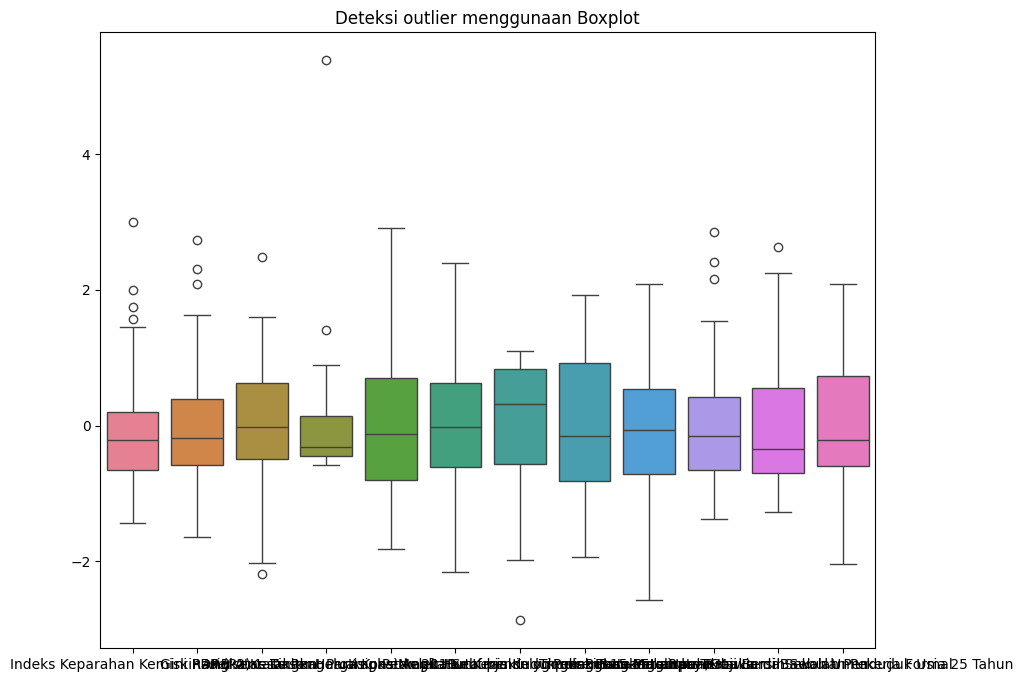

In [6]:
import numpy as np
from scipy import stats
scaler = StandardScaler()
df_scaled = scaler.fit_transform(dataPilihan)
df_scaled = pd.DataFrame(df_scaled, columns=dataPilihan.columns)

z_scores =  np.abs(stats.zscore(df_scaled))
outlier_mask = (z_scores > 3).any(axis=1)

print("Outlier terdeteksi pada:")
data.loc[outlier_mask]
print("Jumlah outlier:", len(data.loc[outlier_mask]))


plt.figure(figsize=(10, 8))
sns.boxplot(data=df_scaled)
plt.title("Deteksi outlier menggunaan Boxplot")
plt.show()

# Membuat Matrix korelasi

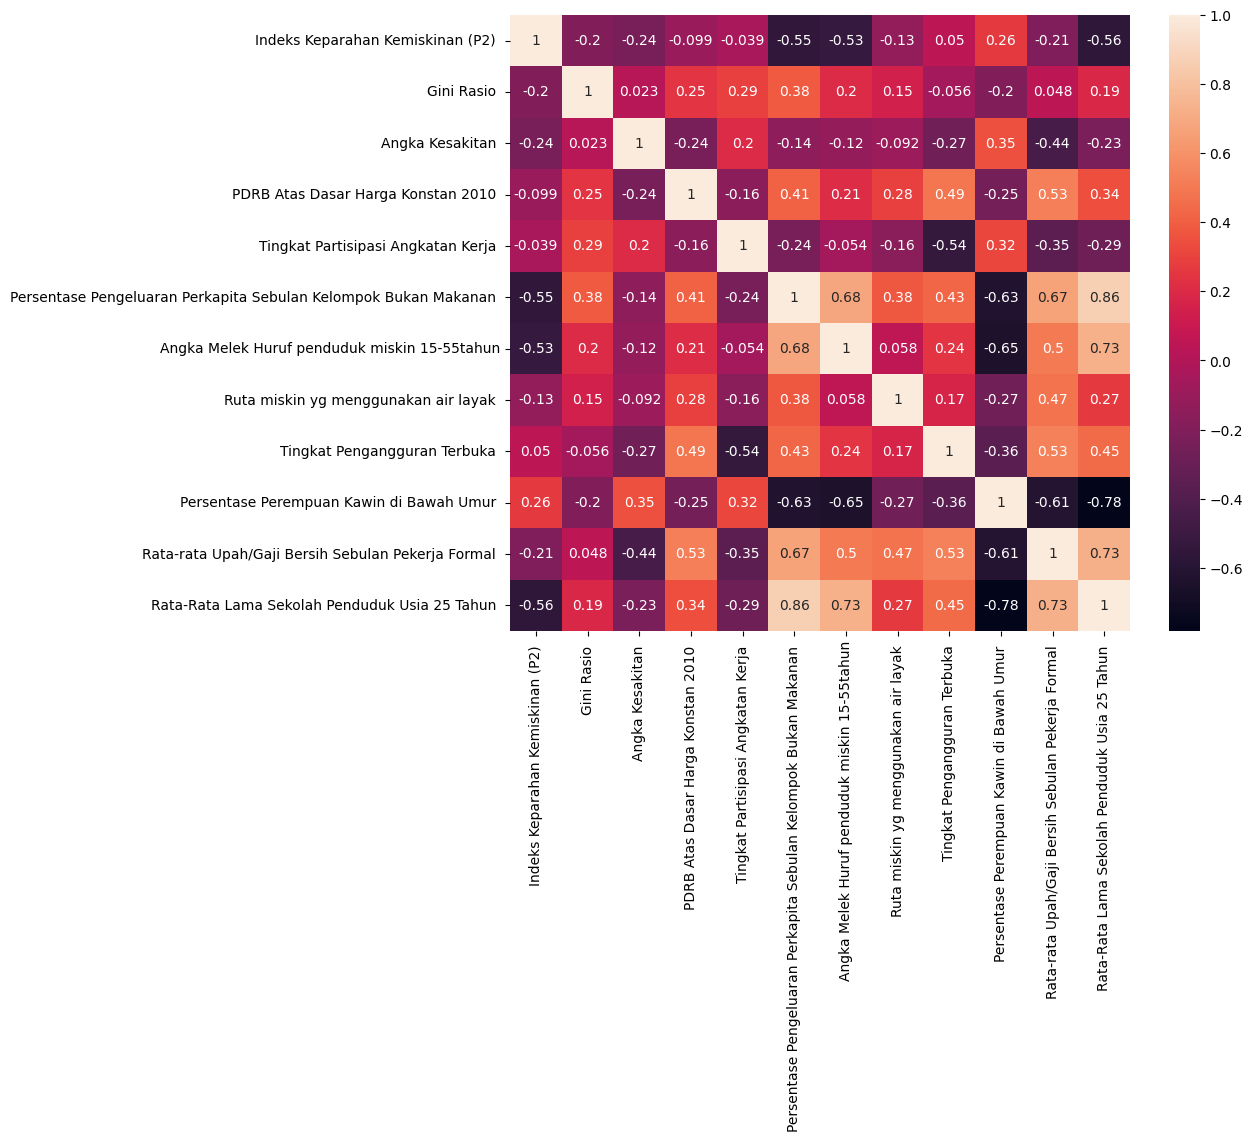

In [7]:
corrr = dataPilihan.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corrr, annot=True)
plt.show()

# Uji kelayakan KMO

In [8]:
def calcularte_kmo(data_sd):
    corr =  np.corrcoef(data_sd.T)
    inv_c = np.linalg.inv(corr)
    d = np.sqrt(np.abs(np.diag(inv_c)))
    AIM =  np.zeros_like(inv_c)
    for  i in range (corr.shape[0]):
        for j in range (corr.shape[1]):
            AIM[i][j] = inv_c[i][j] / (d[i] * d[j])
        np.fill_diagonal(AIM, 1.0)
        r2 = corr**2; np.fill_diagonal(r2, 0)
        a2 = AIM**2; np.fill_diagonal(a2, 0)
        return r2.sum() / (r2.sum() + a2.sum())
    
    
    
def barlet_sphericity(data_sd):
    n,p = data_sd.shape
    corr = np.corrcoef(data_sd.T)
    det_val = np.linalg.det(corr + np.eye(p) * 1e-5)
    chi2 = -(n - 1 - (2*p+5)/6) * np.log(det_val)
    df_stat = p*(p-1)//2
    p_val = 1 - stats.chi2.cdf(chi2, df_stat)
    return chi2, df_stat, p_val

X = df_scaled
kmo_value = calculate_kmo(X)
chi2_stat, df_stat, p_barlettt = barlet_sphericity(X)
kmo_all, kmo_value = kmo_value

print(f"KMO (Kaiser-Meyer-Olkin): {kmo_value:.4f}")
if kmo_value >= 0.8:
    print("  Interpretasi: Sangat Baik (Meritorious)")
elif kmo_value >= 0.7:
    print("  Interpretasi: Baik")
elif kmo_value >= 0.6:
    print("  Interpretasi: Cukup (Mediocre)")
else:
    print("  Interpretasi: Kurang")

print(f"\nBartlett's Test of Sphericity:")
print(f"  Chi-Square : {chi2_stat:.4f}")
print(f"  df         : {df_stat}")
print(f"  p-value    : {p_barlettt:.4e}")
print(f"  Signifikan : {'Ya (p < 0.05) - Matriks korelasi bukan identitas' if p_barlettt < 0.05 else 'Tidak'}")
print("\nKesimpulan: Data LAYAK untuk analisis faktor")

KMO (Kaiser-Meyer-Olkin): 0.7314
  Interpretasi: Baik

Bartlett's Test of Sphericity:
  Chi-Square : 247.4505
  df         : 66
  p-value    : 0.0000e+00
  Signifikan : Ya (p < 0.05) - Matriks korelasi bukan identitas

Kesimpulan: Data LAYAK untuk analisis faktor


# Choose Factor by Eigen Value

In [9]:
pca_all = PCA().fit(X)
eigenvalues =  pca_all.explained_variance_
var_pct = eigenvalues / eigenvalues.sum() * 100
cum_var =  np.cumsum(var_pct)



eigen_df  = pd.DataFrame({
    'Faktor': range(1, len(eigenvalues) + 1),
    'EigenValue ': eigenvalues.round(4),
    'Var. Dijelaskan' : var_pct.round(3),
    'Kumulatif (%)' :cum_var.round(3)
})

n_factor = int((eigenvalues >= 1).sum())
print(f"Jumlah faktor yang diperoleh: {n_factor}")
print(f"Kumulatif varian yang dijelaskan     : {cum_var[n_factor-1]:.2f}%\n")
print("Data layak untuk analisis faktor")

eigen_df

Jumlah faktor yang diperoleh: 4
Kumulatif varian yang dijelaskan     : 75.75%

Data layak untuk analisis faktor


,Faktor,EigenValue,Var. Dijelaskan,Kumulatif (%)
0,1,5.0615,41.069,41.069
1,2,1.9914,16.159,57.228
2,3,1.2529,10.166,67.394
3,4,1.0294,8.353,75.746
4,5,0.8636,7.007,82.753
5,6,0.6315,5.124,87.878
6,7,0.4455,3.615,91.493
7,8,0.3449,2.798,94.291
8,9,0.2423,1.966,96.257
9,10,0.2395,1.943,98.201


# Visualisasi with Scree plot

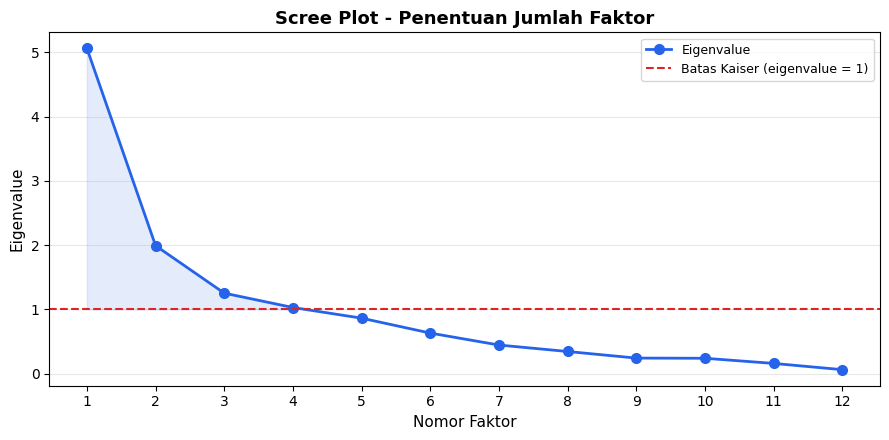

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='#2563EB', linewidth=2, markersize=7, label='Eigenvalue')
ax.axhline(y=1, color='#DC2626', linestyle='--', linewidth=1.5, label='Batas Kaiser (eigenvalue = 1)')
ax.fill_between(range(1, n_factor+1), eigenvalues[:n_factor], 1, alpha=0.12, color='#2563EB')
ax.set_xlabel('Nomor Faktor', fontsize=11)
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title('Scree Plot - Penentuan Jumlah Faktor', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(1, len(eigenvalues)+1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Ekstrasi  factor and rotation varimax

In [11]:
fa = FactorAnalyzer(n_factors=n_factor, rotation="varimax")
fa.fit(dataPilihan)

loadings = pd.DataFrame(
    fa.loadings_,
    index=dataPilihan.columns,
    columns=[f"Faktor {i+1}" for i in range(n_factor)]
)
loadings

,Faktor 1,Faktor 2,Faktor 3,Faktor 4
Indeks Keparahan Kemiskinan (P2),-0.650583,-0.074949,-0.130974,0.454181
Gini Rasio,0.200319,0.288245,0.526869,-0.044431
Angka Kesakitan,-0.088342,-0.187124,0.104626,-0.658630
PDRB Atas Dasar Harga Konstan 2010,0.113771,0.700907,0.014620,0.130368
Tingkat Partisipasi Angkatan Kerja,-0.126656,-0.241060,0.745525,-0.100984
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,0.763210,0.546545,0.022020,-0.049111
Angka Melek Huruf penduduk miskin 15-55tahun,0.813601,0.099918,0.058606,0.078321
Ruta miskin yg menggunakan air layak,0.151113,0.433922,-0.012346,0.041054
Tingkat Pengangguran Terbuka,0.184906,0.527655,-0.467624,0.201238
Persentase Perempuan Kawin di Bawah Umur,-0.713183,-0.221984,0.105278,-0.372397


# Factor Diagram

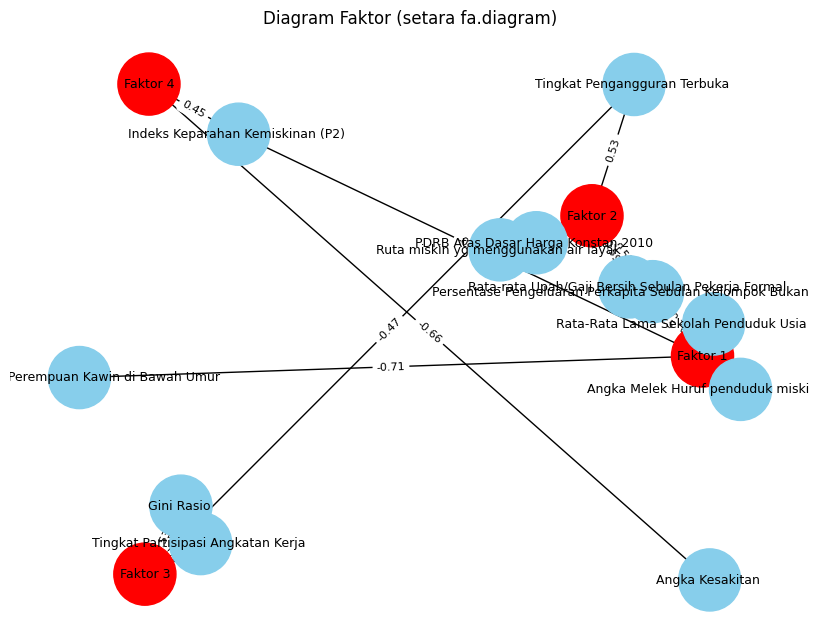

In [13]:
import networkx as nx

loads = loadings.copy()
G = nx.Graph()

for f in loads.columns:
    G.add_node(f, type="factor")

threshold = 0.4
for var in loads.index:
    G.add_node(var, type='variable')
    for f in loads.columns:
        if abs(loads.loc[var, f]) >= threshold:
            G.add_edge(var, f, weight=round(loads.loc[var, f], 2))
            

colors = ['red' if G.nodes[n]['type']=='factor' else 'skyblue' for n in G.nodes]

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=colors,
node_size=2000, font_size=9)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
font_size=8)


plt.title("Diagram Faktor (setara fa.diagram)")
plt.show()

# Visualisasi Diagram with C

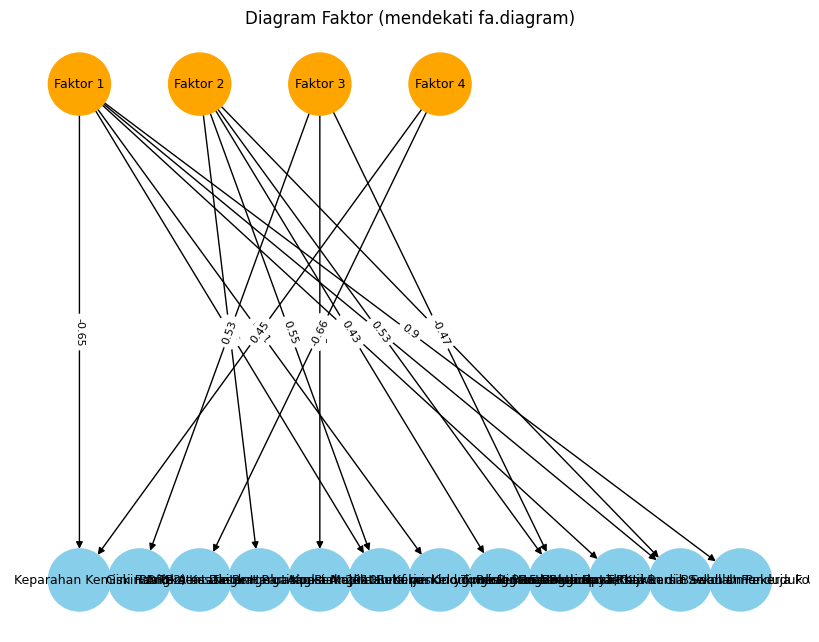

In [14]:
G = nx.DiGraph()
factors = loadings.columns.tolist()
variables = loadings.index.tolist()

pos = {}

for i, f in enumerate(factors):
    pos[f] = (i*2, 2)
    
for i, v in enumerate(variables):
    pos[v] = (i, 0)
    
G.add_nodes_from(factors)
G.add_nodes_from(variables)

threshold = 0.4
for v in variables:
    for f in factors:
        val = loadings.loc[v, f]
        if abs(val) >= threshold:
            G.add_edge(f, v, weight=round(val, 2))

plt.figure(figsize=(8,6))
nx.draw(G, pos,
with_labels=True,
node_color=['orange' if n in factors else 'skyblue' for n in G.nodes],

node_size=2000,font_size=9,arrows=True)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,font_size=8)

plt.title("Diagram Faktor (mendekati fa.diagram)")
plt.axis('off')
plt.savefig("Visual_fa1.png")
plt.show()
